# NAIP Inference — Walmart Parking Lot Occupancy

This notebook runs the fine-tuned ResNet34 U-Net segmentation model on all images located in `Data/naip_images`, restricting the analysis exclusively to the area defined by each store's static mask. 

**Output** → `Data/naip_occupancy_results.csv` with the following columns:

| Column | Description |
|---|---|
| `store_id` | Integer extracted from the filename prefix (e.g., `34` from `34_2019-07-01.png`) |
| `date` | ISO date string extracted from the filename (e.g., `2019-07-01`) |
| `year` | Integer year derived from `date` |
| `occupancy` | Fraction of masked parking lot pixels that are occupied by cars (0.0 – 1.0) |

In the final section of this notebook, we analyze the results obtained by the model to determine it's performance.

## 1 · Setup

In [ ]:
import re
from pathlib import Path
import albumentations as A
import numpy as np
import pandas as pd
import torch
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
from PIL import Image
import segmentation_models_pytorch as smp
import os
import cv2 


# Paths
DATA_ROOT      = Path("../../Data")
NAIP_DIR       = DATA_ROOT / "naip_images"
CHECKPOINT_DIR = Path("../../checkpoints")
OUTPUT_CSV     = DATA_ROOT / "naip_occupancy_results.csv"
MASKS_DIR = DATA_ROOT / "masks"

FT_CKPT   = CHECKPOINT_DIR / "resnet34_unet_walmart_ft.pth"
BASE_CKPT = CHECKPOINT_DIR / "resnet34_unet_best.pth"
CKPT_PATH = FT_CKPT if FT_CKPT.exists() else BASE_CKPT

# Model config (must match training) 
IN_CHANNELS = 3
NUM_CLASSES = 3
IMG_SIZE    = 256

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Device 
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

ckpt_label = "fine-tuned" if CKPT_PATH == FT_CKPT else "base PKLot (fine-tuned not found)"
print(f"Device     : {DEVICE}")
print(f"Checkpoint : {CKPT_PATH}  ({ckpt_label})")
print(f"Images dir : {NAIP_DIR.resolve()}")

Device     : cpu
Checkpoint : ../../checkpoints/resnet34_unet_walmart_ft.pth  (fine-tuned)
Images dir : /Users/gal.lagelpibuxade/Desktop/Application-of-Deep-learning-image/Data/naip_images


In [5]:
model = smp.Unet(
    encoder_name    = "resnet34",
    encoder_weights = None,
    in_channels     = IN_CHANNELS,
    classes         = NUM_CLASSES,
    activation      = None,
)
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()
print(f"Model loaded from {CKPT_PATH.name}, eval mode on {DEVICE}")

Model loaded from resnet34_unet_walmart_ft.pth, eval mode on cpu


Now we have to load all the NAIP images. We know that they are contained in `Data\naip_images`, with the filename format: `{store_id}_{YYYY-MM-DD}.png` where: 
- `store_id` = integer before the first underscore  
- `date`     = ISO date string after the first underscore

In [6]:
all_paths = sorted(NAIP_DIR.glob("*.png"))
print(f"Found {len(all_paths)} PNG files in {NAIP_DIR}\n")

records = []
skipped = []
for p in all_paths:
    m = re.match(r"^(\d+)_(\d{4}-\d{2}-\d{2})", p.stem)
    if m:
        records.append({"path": p, "store_id": int(m.group(1)), "date": m.group(2)})
    else:
        skipped.append(p.name)

print(f"Parsed successfully : {len(records)}")
if skipped:
    print(f"Skipped (no match)  : {skipped}")

# Preview first few
for r in records[:5]:
    print(f"  store={r['store_id']:>5}  date={r['date']}  file={r['path'].name}")

Found 531 PNG files in ../../Data/naip_images

Parsed successfully : 531
  store= 1042  date=2011-08-15  file=1042_2011-08-15.png
  store= 1042  date=2013-09-27  file=1042_2013-09-27.png
  store= 1042  date=2015-08-04  file=1042_2015-08-04.png
  store= 1042  date=2017-09-09  file=1042_2017-09-09.png
  store= 1042  date=2019-11-02  file=1042_2019-11-02.png


## 2 · Run Inference

For each satellite image, the inference pipeline follows these precise steps:

1. **Load and Mask:** Extract the Store ID from the filename to load its corresponding manually defined static mask. This mask is applied to the raw image (via bitwise operations) to black out all irrelevant surroundings (roofs, trees, nearby roads) before feeding it to the network.
2. **Pre-process:** Resize the masked image to 256×256 pixels and normalize it using standard ImageNet statistics.
3. **Model Prediction:** Run the U-Net model (argmax over class logits) to classify each pixel.
4. **Post-process Clean-up:** Enforce strict spatial boundaries by forcing any predictions that fall outside the static mask back to `0` (background).
5. **Compute Occupancy:** Calculate the final ratio based on the actual physical space of the parking lot rather than the model's raw output:
   **occupancy** = `occupied_pixels / total_parking_pixels` (capped at 1.0)
   
   > *Note: `total_parking_pixels` is extracted directly from the area of our static mask, ensuring a stable denominator, while `occupied_pixels` corresponds exclusively to the pixels the model predicted as cars.*

**Class indices:** `0` = background, `1` = space-empty, `2` = space-occupied.

In [7]:
preprocess = A.Compose([
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

def run_inference(image_path: Path) -> float:
    """
    Processes a single satellite image, applies the static store mask,
    and returns the parking lot occupancy rate (0.0 - 1.0).
    """
    # Extract the Store ID from the filename
    match = re.match(r"^(\d+)", image_path.stem)
    if not match:
        print(f"Could not parse Store ID from filename: {image_path.name}")
        return 0.0
    
    store_id = int(match.group(1))
    mask_path = MASKS_DIR / f"mask_store_{store_id}.png"
    
    # Load the original satellite image
    img = np.array(Image.open(image_path).convert("RGB"))
    
    # Apply the mask
    if mask_path.exists():
        mask = np.array(Image.open(mask_path).convert("L")) 
        img = cv2.bitwise_and(img, img, mask=mask)
    else:
        print(f"⚠️ Warning: No mask found for Store ID {store_id}. Processing raw image.")

    # Resize and preprocess the image for the model
    resized = np.array(Image.fromarray(img).resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR))
    tensor = preprocess(image=resized)["image"].unsqueeze(0).to(DEVICE)

    # Model inference
    with torch.no_grad():
        pred = model(tensor).argmax(dim=1).squeeze(0).cpu().numpy() # Matriz (256, 256)

    # Clean up the prediction using the mask, no need to consider areas outside the parking lot
    if mask_path.exists():
        mask_resized = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
        pred[mask_resized == 0] = 0

    # Compute occupancy
    if mask_path.exists():
        # Number of pixels in the parking lot (mask > 0)
        total_parking_pixels = int((mask_resized > 0).sum())
    else:
        total_parking_pixels = IMG_SIZE * IMG_SIZE 

    # Number of pixels predicted as occupied (class 2)
    occupied_pixels = int((pred == 2).sum())
    
    # Compute the occupancy rate, ensuring we don't divide by zero
    occ = occupied_pixels / total_parking_pixels if total_parking_pixels > 0 else 0.0
    return min(occ, 1.0)

# Loop through all images and run inference
rows = []
n    = len(records)
print(f"Running inference on {n} images …")

for i, rec in enumerate(records, 1):
    occ = run_inference(rec["path"])
    rows.append({"store_id": rec["store_id"], "date": rec["date"], "occupancy": occ})
    if i % 50 == 0 or i == n:
        print(f"  [{i:>3}/{n}] last: store={rec['store_id']}  {rec['date']}  occ={occ:.3f}")

print("\nDone.")

Running inference on 531 images …
  [ 50/531] last: store=1530  2023-08-16  occ=0.041
  [100/531] last: store=1973  2018-07-19  occ=0.073
  [150/531] last: store=2455  2018-10-20  occ=0.062
  [200/531] last: store=2781  2023-09-19  occ=0.055
  [250/531] last: store=3091  2020-11-30  occ=0.052
  [300/531] last: store=3311  2023-10-08  occ=0.038
  [350/531] last: store=3587  2023-09-15  occ=0.080
  [400/531] last: store=3956  2016-05-16  occ=0.067
  [450/531] last: store=425  2022-06-06  occ=0.101
  [500/531] last: store=711  2023-08-31  occ=0.028
  [531/531] last: store=938  2023-07-30  occ=0.023

Done.


We save teh results as a csv file:

In [8]:
df = pd.DataFrame(rows)
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df = df.sort_values(["store_id", "date"]).reset_index(drop=True)

df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved {len(df)} rows → {OUTPUT_CSV.resolve()}\n")
df.head(10)

Saved 531 rows → /Users/gal.lagelpibuxade/Desktop/Application-of-Deep-learning-image/Data/naip_occupancy_results.csv



,store_id,date,occupancy,year
0,42,2012-06-22,0.042379,2012
1,42,2015-08-20,0.048267,2015
2,42,2023-06-06,0.029109,2023
3,111,2012-06-25,0.027813,2012
4,111,2014-07-05,0.035563,2014
5,111,2018-11-28,0.020677,2018
6,111,2021-10-18,0.047261,2021
7,111,2023-08-26,0.036177,2023
8,115,2010-08-09,0.015148,2010
9,115,2013-08-07,0.023931,2013


## 3 · Analysis 

First we plot the mean occupancy rate across all stores and images grouped by calendar year. This is going to be the variable we will compare to the Nominal Walmart Sales.

Average occupancy per year

  Year    Mean occ       Std   N images
────────────────────────────────────────
  2010        5.9%      3.3%         40
  2011        6.0%      3.2%         33
  2012        3.9%      2.2%         33
  2013        4.6%      3.5%         41
  2014        5.3%      3.4%         30
  2015        5.0%      3.4%         38
  2016        5.0%      3.4%         33
  2017        5.7%      4.6%         37
  2018        6.4%      3.9%         42
  2019        7.0%      3.6%         31
  2020        5.2%      2.7%         26
  2021        6.7%      3.0%         47
  2022        6.5%      3.2%         39
  2023        4.6%      2.8%         61


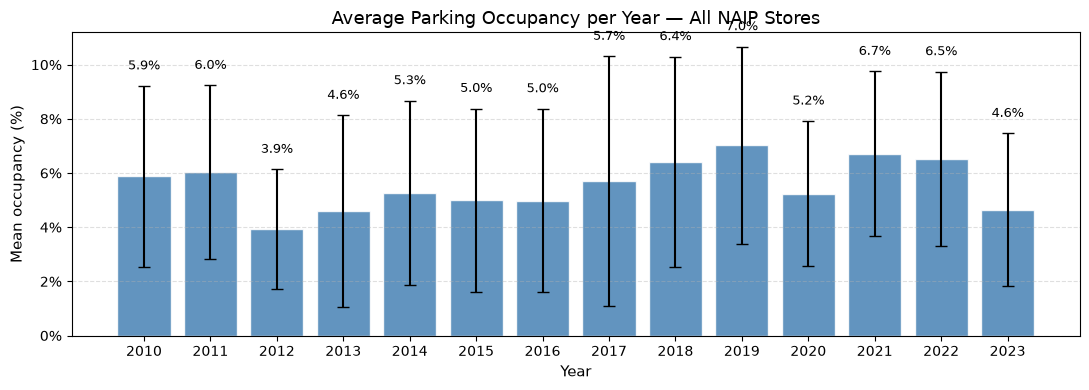

In [10]:
avg_occ = (
    df.groupby("year")["occupancy"]
    .agg(mean_occupancy="mean", std_occupancy="std", n_images="count")
    .reset_index()
)
avg_occ["mean_pct"] = avg_occ["mean_occupancy"] * 100
avg_occ["std_pct"]  = avg_occ["std_occupancy"]  * 100

print("Average occupancy per year\n")
print(f"{'Year':>6}  {'Mean occ':>10}  {'Std':>8}  {'N images':>9}")
print("─" * 40)
for _, row in avg_occ.iterrows():
    print(f"{int(row.year):>6}  {row.mean_pct:>9.1f}%  {row.std_pct:>7.1f}%  {int(row.n_images):>9}")

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(avg_occ["year"], avg_occ["mean_pct"],
       yerr=avg_occ["std_pct"], capsize=4,
       color="steelblue", edgecolor="white", alpha=0.85)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Mean occupancy (%)", fontsize=11)
ax.set_title("Average Parking Occupancy per Year — All NAIP Stores", fontsize=13)
ax.set_xticks(avg_occ["year"])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.grid(axis="y", linestyle="--", alpha=0.4)
for x, y in zip(avg_occ["year"], avg_occ["mean_pct"]):
    ax.text(x, y + avg_occ.loc[avg_occ.year == x, "std_pct"].values[0] + 0.5,
            f"{y:.1f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

Finally we are going to look at some examples of how the model is performing:

Processing and organizing 10 images...



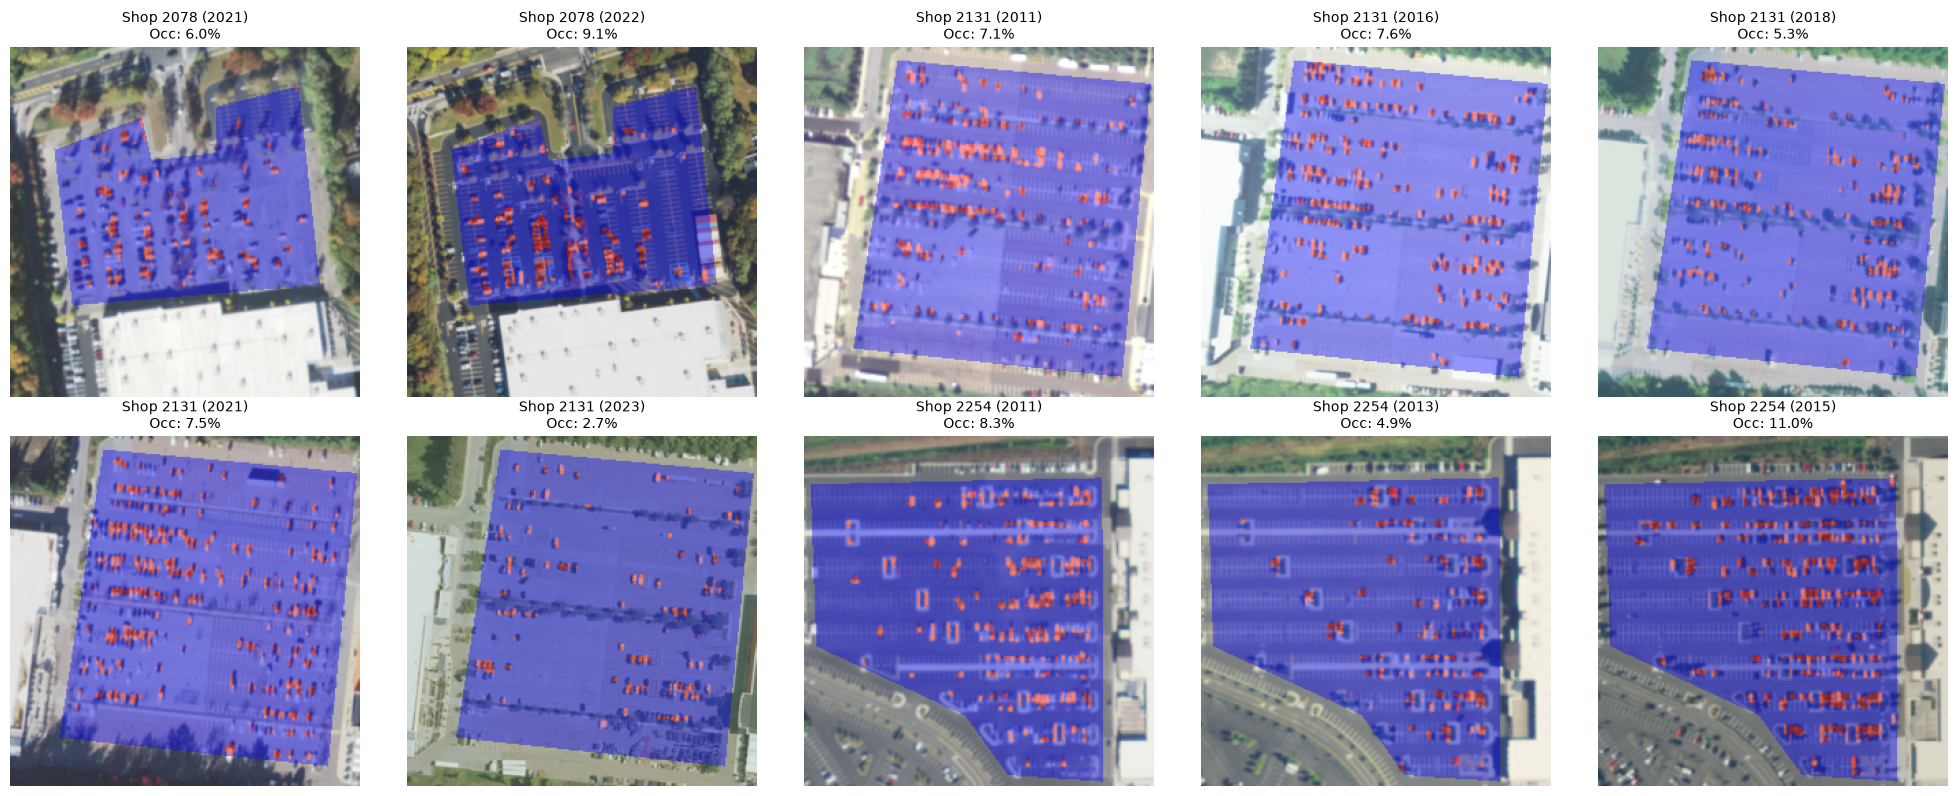

Plotting completed. You should see the 50 predictions displayed with the new color format.


In [21]:
sample = records[112:122]

print(f"Processing and organizing {len(sample)} images...\n")

model.eval()

# Plot configuration
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 8))
axes = axes.flatten()

for idx, rec in enumerate(sample):
    image_path = rec["path"]
    store_id = rec["store_id"]

    # Get the original image and resize it for display
    img_original = np.array(Image.open(image_path).convert("RGB"))
    img_original_resized = np.array(
        Image.fromarray(img_original).resize(
            (IMG_SIZE, IMG_SIZE), Image.BILINEAR
        )
    )

    # Apply the store mask
    mask_path = MASKS_DIR / f"mask_store_{store_id}.png"
    if mask_path.exists():
        mask = np.array(Image.open(mask_path).convert("L"))
        img_enmascarada = cv2.bitwise_and(
            img_original, img_original, mask=mask
        )
    else:
        img_enmascarada = img_original.copy()

    # Resize and preprocess the masked image for the model
    resized_para_model = np.array(
        Image.fromarray(img_enmascarada).resize(
            (IMG_SIZE, IMG_SIZE), Image.BILINEAR
        )
    )
    tensor = preprocess(image=resized_para_model)["image"].unsqueeze(0).to(
        DEVICE
    )

    # Model inference
    with torch.no_grad():
        pred = model(tensor).argmax(dim=1).squeeze(0).cpu().numpy()

    if mask_path.exists():
        mask_resized = cv2.resize(
            mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST
        )
        pred[mask_resized == 0] = 0

    is_car = (pred == 2)
    
    if mask_path.exists():
        is_parking = (mask_resized > 0)
        is_empty = is_parking & ~is_car  
        is_outside = ~is_parking        
        total_parking_pixels = int(is_parking.sum())
    else:
        is_empty = ~is_car
        is_outside = np.zeros_like(pred, dtype=bool)
        total_parking_pixels = IMG_SIZE * IMG_SIZE

    occupied_pixels = int(is_car.sum())
    occ = occupied_pixels / total_parking_pixels if total_parking_pixels > 0 else 0.0
    pct = min(occ, 1.0) * 100 

    pred_rgb = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    pred_rgb[is_empty] = [0, 0, 255]  
    pred_rgb[is_car] = [255, 0, 0]   

    # Overlay the prediction on the original image
    overlay = cv2.addWeighted(img_original_resized, 0.6, pred_rgb, 0.4, 0)
    
    # Restauramos la foto 100% original solo para el exterior del parking
    overlay = np.where(is_outside[:, :, None], img_original_resized, overlay)
    ax = axes[idx]
    ax.imshow(overlay)
    fecha = rec.get("date", "N/A")
    anio = str(fecha).split("-")[0] 
    ax.set_title(f"Shop {store_id} ({anio})\nOcc: {pct:.1f}%", fontsize=10)
    ax.axis("off") 

plt.tight_layout()
plt.show()

print(f"Plotting completed. You should see the 50 predictions displayed with the new color format.")